<div align="center">

# Analisi dei Modelli Cosmologici con MCMC  
### (Corso di Astrofisica computazionale Laurea magistrale)

</div>

---

# Introduzione

In questo notebook stimiamo i parametri fondamentali di diversi modelli
ΛCDM, wCDM e w<sub>0</sub> w<sub>a</sub>CDM utilizzando un approccio
Bayesiano basato su catene di Markov Monte Carlo (MCMC) con l’algoritmo
*affine-invariant ensemble sampler* (`emcee`). Il motore della nostra inferenza Bayesiana è la libreria open-source
[`emcee`](https://emcee.readthedocs.io) (Foreman-Mackey et al., 2013),
che implementa l’**ensemble sampler affinely invariant** di Goodman & Weare
(2010). 



**MCMC.** Generiamo campioni dalla distribuzione a posteriori
$p(\boldsymbol\theta \mid \text{dati})$ costruendo una
*catena di Markov* che ha proprio quella distribuzione come stato di
equilibrio. Ogni nuovo punto dipende solo dal precedente: ciò consente
di esplorare spazi di parametro di qualunque dimensione senza grigliare
l’intero volume.

**Ensemble di *walker*.** Invece di una sola catena, `emcee` utilizza
$N$ camminatori che cooperano. I walker si muovono in parallelo,
condividendo informazioni sulla geometria della posterior:
∙ esplorazione più ampia,  
∙ diagnostica d’insieme (autocorrelazione, mixing) più affidabile.

**Invarianza affine.** Le prestazioni restano quasi invariate se
ruotiamo o “allunghiamo” lo spazio dei parametri. In pratica il sampler
non soffre quando la posterior ha la forma di una “banana” (classico
caso di forte correlazione $H_0 –\Omega_m$).

**Stretch move.** Per ogni walker $i$ si sceglie a caso un secondo
walker $j$ e si propone


$$\theta'_i = \theta_j + Z\,(\theta_i - \theta_j), \qquad
Z \sim g(Z).$$

La proposta è accettata con


$$\min\Bigl\{1,\; Z^{\,d-1}\; e^{\Delta\ln\mathcal L}\Bigr\},$$

dove $d$ è la dimensionalità del problema. Questa mossa garantisce
l’invarianza affine.

**Alternative moves.** Dalla versione 3.0 `emcee` offre anche
`DEMove` (Differential Evolution) e `KDEMove`; sono mosse che migliorano
notevolmente il mixing in spazi a >4 dimensioni o con multi-modi
distanti.





In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM, wCDM, w0waCDM
from scipy.constants import c
import emcee, corner 
import sys
sys.path.append("../")    

In [21]:
from pyACC.cosmology.distances import Distances

In [22]:
C_KMS = c / 1000.0  
fid_cosmo = LambdaCDM(H0=67.14, Om0=0.3169, Ode0=1-0.3169)
r_d_fid   = 147.05 

In [23]:
df = pd.read_csv("dati_desi.csv")

In [24]:
mask = df["DV_rd"].notna() & df["DV_rd_err"].notna()
if mask.sum() == 0:
    raise RuntimeError("Nessun punto BAO valido: controlla dvok.csv (DV_rd & DV_rd_err).")

df = df.loc[mask]
print(f"→ {len(df)}/{len(df)} righe BAO utilizzate.")

→ 6/6 righe BAO utilizzate.


In [25]:
z_data      = df["zeff"].to_numpy()
DV_rd_data  = df["DV_rd"].to_numpy()
DV_rd_sigma = df["DV_rd_err"].to_numpy()
alpha_data  = df["alpha_iso"].to_numpy()
alpha_sigma = df["alpha_iso_err"].to_numpy()

### Esempio 1: il modello ΛCDM - le funzioni



#### `dv_model`
Calcola la **volume-averaged distance**

$$
D_V(z)=\left[\frac{c\,z\,D_M^2(z)}{H(z)}\right]^{1/3}
$$


#### `dv_rd_model`
Normalizza $D_V$ dividendo per $r_d = 147.05$ Mpc,
ottenendo l’osservabile $(D_V/r_d)(z)$ confrontabile
con le misure BAO isotropiche DESI.


#### `ln_prior`
Prior uniforme (box) sui parametri:

* $40 < H_0 < 100 \; km \; s^{-1} \; Mpc^{-1}$
* $0.05 < \Omega_m < 0.60$

Dentro il box $\ln p = 0$; fuori $\ln p = -\infty$.

---

#### `build_cosmo`
Traduce la coppia $(H_0,\Omega_m)$ in un oggetto Astropy **`LambdaCDM`**
piatto, fissando $\Omega_\Lambda = 1-\Omega_m$.  
Collega i parametri liberi ai calcoli di $H(z)$ e $D_M(z)$ usati da
`Distances`.

---

#### `ln_likelihood`
Assume errori gaussiani indipendenti sui dati BAO:

$$
\ln\mathcal L \;=\;
-\tfrac12 \sum_i
\left[\frac{(D_V/r_d)^{\text{obs}}_i - (D_V/r_d)^{\text{mod}}_i}
{\sigma_i}\right]^2 .
$$

È la forma classica del $\chi^2$.

---

#### `ln_posterior`
Combina prior e likelihood secondo Bayes:

$$
\ln p(\theta\mid\text{dati}) \;=\;
\ln\mathcal L(\text{dati}\mid\theta) \;+\; \ln p(\theta) \;+\;\text{cost.}
$$

Se la proposta viola il prior, restituisce immediatamente $-\infty$.

---

Il processo prende avvio con l’inizializzazione dei walker, distribuiti
in modo uniforme all’interno del box-prior. Successivamente il sampler
affine-invariant di **`emcee`** propone nuove coppie di parametri
$(H_0,\Omega_m)$; ciascuna proposta viene valutata dalla funzione
`ln_posterior`, che combina prior e likelihood. Terminata la fase di
*burn-in*, la catena esplora effettivamente la distribuzione posterior e
fornisce campioni utili per l’inferenza. Da questi campioni ricaviamo la
mediana dei parametri, l’intervallo di credibilità al 68 % e la curva
best-fit. In sintesi, l’utilizzo di `Distances` garantisce coerenza con
la pipeline DESI, mentre il sampler affine-invariant di `emcee`
assicura un’inferenza Bayesiana rapida e robusta anche in presenza di
forti correlazioni fra i parametri.


In [26]:
def dv_model(z, cosmo):
    """Volume‑averaged distance Dᵥ (Eisenstein+2005)."""
    Dc = cosmo.comoving_distance(z).value           # [Mpc]
    H  = cosmo.H(z).value                           # [km s⁻¹ Mpc⁻¹]
    return ( (C_KMS * z * Dc**2) / H )**(1/3)       # [Mpc]

r_d_model = 147.05 

def dv_rd_model(z, cosmo):
    return dv_model(z, cosmo) / r_d_model


def ln_prior(theta):
    H0, Om0 = theta
    if 40 < H0 < 100 and 0.05 < Om0 < 0.6:
        return 0.0  # si assume una flat prior dentro il box
    return -np.inf


def build_cosmo(theta):
    H0, Om0 = theta
    return LambdaCDM(H0=H0, Om0=Om0, Ode0=1-Om0)


def ln_likelihood(theta):
    cosmo = build_cosmo(theta)
    model = dv_rd_model(z_data, cosmo)
    return -0.5 * np.sum(((DV_rd_data - model) / DV_rd_sigma)**2)


def ln_posterior(theta):
    lp = ln_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + ln_likelihood(theta)


### Esempio 1: per il modello ΛCDM - l'algoritmo di emcee

In questa parte del notebook stimiamo i due parametri liberi del modello,
$H_0$ e $\Omega_m$.  Impostiamo quindi `ndim = 2`.  
Per il campionamento usiamo `nwalk = 32`: in pratica lanciamo **32
catene parallele** (i walker), seguendo la regola empirica “il numero
dei walker deve essere almeno il doppio del numero dei parametri”,
così il mixing è garantito.

Ogni catena viene fatta evolvere per `nsteps = 5000` passi. Dei campioni
prodotti scarteremo i primi `burn = 2000` passi – questa fase di
*burn-in* serve a eliminare la dipendenza dalle condizioni iniziali.

Il seme `rng = np.random.default_rng(42)` rende tutto riproducibile:
stessi numeri casuali, stessi risultati.  
I walker non partono da un singolo “guess” ma da posizioni uniformemente
estratte nel box-prior $40 < H_0 < 100 \; km^{-1} \; Mpc^{-1}$ e $0.05 < \Omega_m < 0.60$,
evitando qualsiasi bias iniziale

---

Il campionamento vero e proprio inizia con la creazione dell’oggetto `sampler`,
che implementa l’algoritmo affine-invariant di **`emcee`**. 

**Costruzione del sampler**  
`sampler = emcee.EnsembleSampler(nwalk, ndim, ln_posterior)`  
Qui inizializziamo l’oggetto `EnsembleSampler`, fornendogli:  
* il numero di walker (`nwalk = 32`),  
* la dimensionalità dello spazio dei parametri (`ndim = 2`),  
* il puntatore alla funzione `ln_posterior`.  
Il sampler implementa l’algoritmo *affine-invariant ensemble* di
Goodman & Weare, capace di esplorare anche distribuzioni posteriori
fortemente correlate. 

**Esecuzione della catena**  
`sampler.run_mcmc(p0, nsteps, progress=True)`  
Ogni walker parte dalla propria posizione iniziale `p0` e compie
`nsteps = 5000` iterazioni. L’opzione `progress=True` visualizza la
barra di avanzamento con il tasso di accettazione.

**Srotolamento post-burn-in**  
`flat_chain = sampler.get_chain(discard=burn, flat=True)`  
Scartiamo i primi `burn = 2000` passi (*burn-in*) e appiattiamo
l’array: otteniamo $32 \times 3000 = 96{,}000$ campioni indipendenti
della distribuzione a posteriori $p(H_0,\Omega_m \mid \text{dati})$.

**Stima puntuale dei parametri**  
`best_H0, best_Om0 = np.median(flat_chain, axis=0)`  
La mediana dei campioni viene scelta come stima puntuale.
**Costruzione della cosmologia best-fit**  
`cosmo_best = LambdaCDM(H0=best_H0, Om0=best_Om0, Ode0=1-best_Om0)`  
Con i valori mediani creiamo l’oggetto Astropy `LambdaCDM`
corrispondente, imponendo l’universalità della piattezza
($\Omega_\Lambda = 1 - \Omega_m$). Questa cosmologia verrà impiegata per
tracciare la curva teorica e calcolare gli intervalli di confidenza nel
confronto con i dati BAO.


In [27]:
ndim  = 2
nwalk = 32
nsteps = 5000
burn   = 2000
rng    = np.random.default_rng(42)

p0 = rng.uniform(low=[40,0.05], high=[100,0.6], size=(nwalk, ndim))
sampler = emcee.EnsembleSampler(nwalk, ndim, ln_posterior)
sampler.run_mcmc(p0, nsteps, progress=True)
flat_chain = sampler.get_chain(discard=burn, flat=True)
best_H0, best_Om0 = np.median(flat_chain, axis=0) #la mediana della flat chain lungo le due colonne
cosmo_best = LambdaCDM(H0=best_H0, Om0=best_Om0, Ode0=1-best_Om0)

  0%|          | 0/5000 [00:00<?, ?it/s]

  5%|▌         | 263/5000 [00:06<01:51, 42.42it/s]Traceback (most recent call last):
  File "/home/asiat/anaconda3/envs/acc-env/lib/python3.12/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_154116/2372380809.py", line 33, in ln_posterior
    if not np.isfinite(lp):
           ^^^^^^^^^^^^^^^
KeyboardInterrupt
  5%|▌         | 265/5000 [00:06<02:03, 38.33it/s]


emcee: Exception while calling your likelihood function:
  params: [66.8669857   0.33637533]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 

Il codice ricava **valori centrali e incertezze a $1\sigma$** per i due
parametri campionati, $H_0$ e $\Omega_m$.

* `np.percentile(flat_chain[:, 0], [16, 50, 84])` restituisce il
  16°, 50° (mediana) e 84° percentile della distribuzione a posteriori
  di $H_0$; la stessa operazione sulla seconda colonna fornisce i
  percentili per $\Omega_m$.

* Le incertezze sono calcolate come scarti asimmetrici:

  $$
  \sigma_{+} = P_{84} - P_{50}, \qquad
  \sigma_{-} = P_{50} - P_{16},
  $$

  dove $P_{q}$ indica il $q$-esimo percentile.  
  Questa scelta è adatta a posterior non perfettamente simmetriche.


il numero centrale del print finale è la mediana e i termini “$+\sigma_{+}$”,
“$-\sigma_{-}$” rappresentano l’intervallo di credibilità al 68 %
(l’equivalente Bayesiano del $1\sigma$ gaussiano, ma calcolato senza
assumere simmetria della distribuzione).





In [ ]:
H0_16, H0_50, H0_84   = np.percentile(flat_chain[:, 0], [16, 50, 84])
Om0_16, Om0_50, Om0_84 = np.percentile(flat_chain[:, 1], [16, 50, 84])

H0_err_plus  = H0_84 - H0_50
H0_err_minus = H0_50 - H0_16
Om_err_plus  = Om0_84 - Om0_50
Om_err_minus = Om0_50 - Om0_16

print(f"H0   = {H0_50:.2f}  +{H0_err_plus:.2f}  -{H0_err_minus:.2f}  km/s/Mpc")
print(f"Ω_m  = {Om0_50:.3f} +{Om_err_plus:.3f} -{Om_err_minus:.3f}")

H0   = 69.31  +0.81  -0.82  km/s/Mpc
Ω_m  = 0.293 +0.015 -0.015


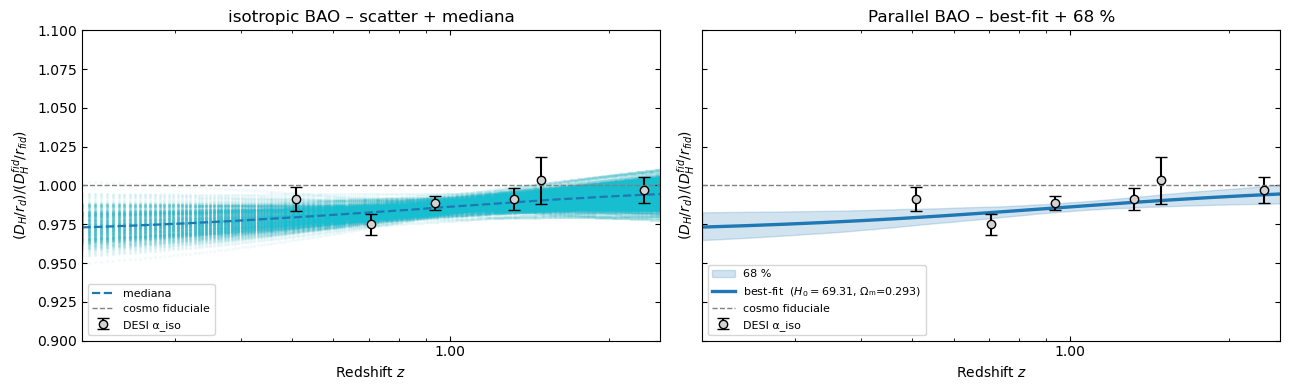

In [28]:
from matplotlib.ticker import ScalarFormatter

z_dense      = np.linspace(0.2, 2.5, 400) #un vettore di 400 punti equispaziati tra 0.2 e 2.5
Dv_fid_dense = dv_model(z_dense, fid_cosmo) #DV della cosmologia fiduciale per i punti z_dense

n_band   = min(800, flat_chain.shape[0]) # limito a 800 il numero di campioni da usare per disegnare la banda di incertezza
idx_band = rng.choice(flat_chain.shape[0], size=n_band, replace=False) # indici casuali (senza ripetizione) che selezionano n_band righe da flat_chain.

alpha_mat = np.array([
    dv_rd_model(z_dense, build_cosmo(theta)) / (Dv_fid_dense / r_d_fid)
    for theta in flat_chain[idx_band] # per ogni riga di flat_chain[idx_band] calcola il DV normalizzato
])   

idx_all = np.arange(flat_chain.shape[0])

alpha_med  = np.median(alpha_mat, axis=0) # mediana dei n_band valori di α
alpha_low  = np.percentile(alpha_mat, 16, axis=0)
alpha_high = np.percentile(alpha_mat, 84, axis=0)

# parametri mediani curva best-fit
best_H0, best_Om0 = np.median(flat_chain, axis=0)
cosmo_best = LambdaCDM(H0=best_H0, Om0=best_Om0, Ode0=1-best_Om0)
alpha_best = dv_rd_model(z_dense, cosmo_best) / (Dv_fid_dense / r_d_fid)


fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

scat_idx = rng.choice(n_band, size=min(300, n_band), replace=False) #di un sotto-insieme di 300 traiettorie per dare un’idea della dispersione delle catene.
axL.scatter(np.tile(z_dense, scat_idx.size),
            alpha_mat[scat_idx].ravel(),
            s=2, alpha=0.04, color="tab:cyan")
axL.plot(z_dense, alpha_med, ls="--", lw=1.6,
         color="tab:blue", label="mediana ")

axL.errorbar(z_data, alpha_data, yerr=alpha_sigma,
             fmt="o", ms=6, mfc="lightgray", mec="k",
             ecolor="k", capsize=4, label="DESI α_iso")
axL.axhline(1, ls="--", lw=1, color="grey", label="cosmo fiduciale")
axL.set_title("isotropic BAO – scatter + mediana")

# best-fit + 68 %
axR.fill_between(z_dense, alpha_low, alpha_high,
                 color="tab:blue", alpha=0.20, label="68 % ")
axR.plot(z_dense, alpha_best, lw=2.4, color="tab:blue",
         label=fr"best-fit  ($H_0={best_H0:.2f}$, Ωₘ={best_Om0:.3f})")

axR.errorbar(z_data, alpha_data, yerr=alpha_sigma,
             fmt="o", ms=6, mfc="lightgray", mec="k",
             ecolor="k", capsize=4, label="DESI α_iso")
axR.axhline(1, ls="--", lw=1, color="grey", label="cosmo fiduciale")
axR.set_title("Parallel BAO – best-fit + 68 %")


for ax in (axL, axR):
    ax.set_xscale("log")
    ax.set_xlabel("Redshift $z$")
    ax.set_ylabel(r'$(D_H/r_d)/(D_H^{fid}/r_{fid})$')
    ax.set_xlim(0.2, 2.5)
    ax.set_ylim(0.9, 1.1)

    for spine in ax.spines.values():
        spine.set_visible(True)

    ax.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True,
                   labeltop=False, labelright=False)

    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.get_major_formatter().set_scientific(False)
    ax.xaxis.get_major_formatter().set_useOffset(False)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.get_major_formatter().set_scientific(False)
    ax.yaxis.get_major_formatter().set_useOffset(False)

    ax.legend(fontsize=8, loc='lower left')

fig.tight_layout()
plt.show()


La figura è composta da due pannelli affiancati, entrambi in scala
logaritmica sull’asse delle ascisse (0.2 ≤ $z$ ≤ 2.5).  
L’ordinata rappresenta il rapporto normalizzato
$(D_H/r_d)/(D_H^{\text{fid}}/r_{d,\text{fid}})$, in modo che la linea
orizzontale a quota 1 segnali la cosmologia di riferimento.

**Pannello sinistro – scatter + mediana**  
– I puntini ciano (300 estratti dalla catena) visualizzano la dispersione
degli $\alpha(z)$ generati dai campioni MCMC; la loro densità indica
dove la posterior concentra maggiore probabilità.  
– La curva tratteggiata blu è la funzione $\alpha(z)$ calcolata con la
mediana bayesiana dei parametri ($50^{\text{mo}}$ percentile).  
– I cerchietti DESI, con riempimento grigio e bordo nero, mostrano i
dati osservativi e le relative incertezze verticali.

**Pannello destro – best-fit + fascia 68 %**  
– L’area azzurra racchiude l’intervallo di credibilità al 68 %,
compreso tra i percentili 16 e 84 della distribuzione a posteriori di
$\alpha(z)$.  
– La curva blu spessa è la previsione del modello calcolata con i
parametri mediani riportati in legenda. Essa rappresenta la soluzione “best-fit” nel senso
bayesiano.  
– Anche qui compaiono i punti DESI e la linea orizzontale della
cosmologia fiduciale.




## Esempio 2: per i modelli di DESI 

Finora abbiamo analizzato un singolo modello cosmologico. L’obiettivo ora è **estendere** lo stesso workflow a più configurazioni teoriche, in modo da confrontare parametri e risultati in un’unica soluzione automatizzata.

Ogni modello cosmologico è associato a tre proprietà:

- `ndim` – numero di parametri da esplorare  
- `tag` – etichetta compatta per identificazione e nomi di file  
- `color` – colore per la rappresentazione grafica  

In [32]:
from astropy.cosmology import LambdaCDM, wCDM, w0waCDM

In [33]:
models = {
    "LCDM_flat"   : dict(ndim=2,  tag="lcdm",      color="black"),
    "wCDM_flat"   : dict(ndim=3,  tag="wcdm",      color="cyan"),
    "w0waCDM_flat"   : dict(ndim=4,  tag="w0wa_des",  color="green"),
    #"w0wa_lit"    : dict(ndim=4,  tag="w0wa_lit",  color="red"),
    "LCDM_Ok"     : dict(ndim=3,  tag="lcdm_ok",   color="purple"),
    "w0wa_Ok"     : dict(ndim=5,  tag="w0wa_ok",   color="orange"),
}

La prima funzione `unpack_theta` trasforma l’array `theta` nei parametri cosmologici **H0**, **Om**, **Ok**, **w0**, **wa** in base al modello selezionato (`tag`):

- **lcdm** : H0, Om  

- **lcdm_ok** :  H0, Om, Ok  

- **wcdm** : H0, Om, w0  

- **w0wa\*** : H0, Om, w0, wa  

- **w0wa_ok** : H0, Om, w0, wa, Ok  

In tutti i casi il risultato è un dizionario con chiavi **H0**, **Om**, **Ok**, **w0**, **wa**; i parametri non previsti dal modello vengono impostati a `None`.  

La funzione `ln_prior_new` verifica che ogni parametro estratto da `theta` rientri nei limiti definiti in `bounds_new` e soddisfi il vincolo di densità $\Omega_\Lambda = 1 - \Omega_m - \Omega_k > 0$. Se tutte le condizioni sono soddisfatte restituisce log-prior pari a 0, altrimenti ritorna $-\infty$.

La funzione `build_cosmo_new` a partire dai parametri mappati con `unpack_theta`, crea l’oggetto di **astropy.cosmology** corrispondente al modello:  
- **lcdm**: istanza di `LambdaCDM` con $\Omega_k = 0$.  
- **lcdm_ok**: `LambdaCDM` con $\Omega_k \neq 0$.  
- **wcdm**: `wCDM` con equazione di stato costante $w_0$.  
- **w0wa***: `w0waCDM` con parametri $w_0$ e $w_a$.  
- **w0wa_ok**: `w0waCDM` con anche $\Omega_k$.  

La funzione `ln_likelihood_new` Calcola la verosimiglianza dei dati rispetto al modello cosmologico:  
1. Costruisce la cosmologia tramite `build_cosmo_new`.  
2. Calcola il modello di distanza `dv_rd_model(z_data, cosmo)`.  
3. Se il risultato contiene **NaN** o **∞**, ritorna $-\infty$.  
4. Altrimenti calcola il $\chi^2$ sui dati misurati e restituisce  
   
    $$ \ln\mathcal{L} = -\frac{1}{2}\sum\biggl(\frac{DV\_rd\_data - model}{DV\_rd\_sigma}\biggr)^2 $$

La funzione `ln_posterior_new` somma il log-prior e il log-likelihood per ottenere il log-posterior:  
- Se il log-prior è $-\infty$, restituisce $-\infty$.  
- Altrimenti restituisce $\ln p(\theta) + \ln\mathcal{L}(\theta)$.

Pertanto, variando la log-prior e di conseguenza la log-posterior, si influenzano direttamente i modelli cosmologici esplorati nelle catene di campionamento.  

In [35]:
# Range consentito per i parametri cosmologici
bounds_new = dict(
    H0=(30.0, 110.0), Om=(0.01, 0.80),
    Ok=(-0.30, 0.30),  w0=(-2.5, -0.3), wa=(-5.0, 2.0)
)

# theta = [H0, Om, Ok, w0, wa] è l'array dei parametri cosmologic
def unpack_theta(theta, tag):
    if tag == "lcdm":
        return dict(H0=theta[0], Om=theta[1], Ok=None, w0=None, wa=None)
    if tag == "lcdm_ok":
        return dict(H0=theta[0], Om=theta[1], Ok=theta[2], w0=None, wa=None)
    if tag == "wcdm":
        return dict(H0=theta[0], Om=theta[1], Ok=None, w0=theta[2], wa=None)
    if tag.startswith("w0wa") and "ok" not in tag:
        return dict(H0=theta[0], Om=theta[1], Ok=None, w0=theta[2], wa=theta[3])
    if tag == "w0wa_ok":
        return dict(H0=theta[0], Om=theta[1], Ok=theta[4], w0=theta[2], wa=theta[3])
    raise ValueError(tag)

def ln_prior_new(theta, tag):
    p = unpack_theta(theta, tag)

    cond = bounds_new["H0"][0] < p["H0"] < bounds_new["H0"][1] and \
           bounds_new["Om"][0] < p["Om"] < bounds_new["Om"][1]

    if "ok"   in tag:
        cond &= bounds_new["Ok"][0] < p["Ok"] < bounds_new["Ok"][1]
    if tag == "wcdm" or tag.startswith("w0wa"):
        cond &= bounds_new["w0"][0] < p["w0"] < bounds_new["w0"][1]
    if tag.startswith("w0wa"):
        cond &= bounds_new["wa"][0] < p["wa"] < bounds_new["wa"][1]

    Ok_val = p["Ok"] if p["Ok"] is not None else 0.0
    cond &= (1 - p["Om"] - Ok_val) > 0

    return 0.0 if cond else -np.inf

def build_cosmo_new(theta, tag):
    p = unpack_theta(theta, tag)
    if tag == "lcdm":
        return LambdaCDM(H0=p["H0"], Om0=p["Om"], Ode0=1-p["Om"])
    if tag == "lcdm_ok":
        return LambdaCDM(H0=p["H0"], Om0=p["Om"], Ode0=1-p["Om"]-p["Ok"])
    if tag == "wcdm":
        return wCDM(H0=p["H0"], Om0=p["Om"], Ode0=1-p["Om"], w0=p["w0"])
    if tag.startswith("w0wa") and "ok" not in tag:
        return w0waCDM(H0=p["H0"], Om0=p["Om"], Ode0=1-p["Om"],
                       w0=p["w0"], wa=p["wa"])
    if tag == "w0wa_ok":
        return w0waCDM(H0=p["H0"], Om0=p["Om"], Ode0=1-p["Om"]-p["Ok"],
                       w0=p["w0"], wa=p["wa"])
    raise ValueError(tag)

def ln_likelihood_new(theta, tag):
    try:
        cosmo = build_cosmo_new(theta, tag)
        model = dv_rd_model(z_data, cosmo)
        if np.any(~np.isfinite(model)):          
            return -np.inf
        chi2 = np.sum(((DV_rd_data - model) / DV_rd_sigma) ** 2)
        return -0.5 * chi2
    except Exception:                            
        return -np.inf

def ln_posterior_new(theta, tag):
    lp = ln_prior_new(theta, tag)
    return lp + ln_likelihood_new(theta, tag) if np.isfinite(lp) else -np.inf


- **Generatore di numeri casuali**  
  Viene inizializzato con seed fisso (`42`) per garantire riproducibilità dei risultati.  
- **Parametri globali**  
  - `nsteps = 1000`: numero di passi per ciascuna catena MCMC  
  - `thin_by = 2`: fattore di thinning per ridurre la correlazione tra campioni (si conserva un campione ogni 2)  

Per ciascun modello definito in `models`:

1. **Numero di dimensioni**  
   Si recupera `ndim` dal dizionario di configurazione.  
2. **Numero di walker**  
   Viene scelto come il massimo tra `2·ndim` e `20`, garantendo un minimo di 20 camminatori per una buona esplorazione del parametro.  
3. **Intervalli iniziali (`low`, `high`)**  
   - Sempre presenti: H0 e Ωₘ  
   - Se il modello prevede w₀: si aggiunge l’intervallo per w₀  
   - Se prevede wₐ: si aggiunge l’intervallo per wₐ  
   - Se prevede Ωₖ: si aggiunge l’intervallo per Ωₖ  
4. **Posizioni iniziali (`p0`)**  
   Si estraggono in modo uniforme nell’iperspazio definito da `low` e `high`, con forma `(nwalk, ndim)`.


- **Creazione del sampler**  
  ```python
  sampler = emcee.EnsembleSampler(nwalk, ndim, ln_posterior_new, args=(tag,))


In [36]:
rng = np.random.default_rng(42)
nsteps, thin_by = 1000, 2
samplers = {}

for name, cfg in models.items():
    ndim, tag = cfg["ndim"], cfg["tag"]
    nwalk     = max(2*ndim, 20)
    low  = [bounds_new["H0"][0], bounds_new["Om"][0]]
    high = [bounds_new["H0"][1], bounds_new["Om"][1]]
    if "w" in tag:
        low += [bounds_new["w0"][0]];  high += [bounds_new["w0"][1]]
    if "w0wa" in tag:
        low += [bounds_new["wa"][0]];  high += [bounds_new["wa"][1]]
    if "ok" in tag:
        low += [bounds_new["Ok"][0]];  high += [bounds_new["Ok"][1]]

    p0 = rng.uniform(low=low, high=high, size=(nwalk, ndim))
    sampler = emcee.EnsembleSampler(nwalk, ndim, ln_posterior_new, args=(tag,))
    print(f"→ {name}: {nwalk} walker, {ndim} dim, 1 000 step")
    sampler.run_mcmc(p0, nsteps, thin_by=thin_by, progress=True)
    samplers[name] = sampler
print("✓ tutte le catene concluse")

→ LCDM_flat: 20 walker, 2 dim, 1 000 step


  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:32<00:00, 61.37it/s]


→ wCDM_flat: 20 walker, 3 dim, 1 000 step


100%|██████████| 2000/2000 [00:34<00:00, 58.38it/s]


...

→ LCDM_Ok: 20 walker, 3 dim, 1 000 step


100%|██████████| 2000/2000 [00:30<00:00, 66.66it/s]
/home/asiat/anaconda3/envs/acc-env/lib/python3.12/site-packages/astropy/cosmology/flrw/base.py:850: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(


→ w0wa_Ok: 20 walker, 5 dim, 1 000 step


  0%|          | 0/2000 [00:00<?, ?it/s]/home/asiat/anaconda3/envs/acc-env/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [00:25<00:00, 79.34it/s]

✓ tutte le catene concluse


In questa fase estraiamo dalla catena MCMC le diverse stime “puntuali” dei parametri e le usiamo per costruire le curve teoriche.

### 1. Mediana del campione (best-fit median)  
- **Definizione:** mediana di ciascuna distribuzione marginale dei parametri \(\theta\).  
- **Interpretazione teorica:** per ogni parametro, il 50 % dei campioni ha valore minore e il 50 % valore maggiore.  
- **Uso:** fornisce una stima “robusta” contro code asimmetriche o outlier nella posterior.

### 2. MAP (Maximum A Posteriori)  
- **Definizione:** il vettore di parametri \(\theta_{\rm MAP}\) che **massimizza** la densità di posterior \(p(\theta\mid{\rm dati})\).  
- **Interpretazione teorica:** è il punto di massima credibilità a posteriori, equivalente al massimo della log-posterior.  
- **Uso:** rappresenta il “picco” della distribuzione congiunta e spesso coincide con la migliore compatibilità complessiva tra prior e likelihood.

In [37]:
scatter_map = {
    "black": "dimgray",
    "cyan":  "lightcyan",
    "green": "lightgreen",
    "red":   "lightcoral",
    "purple":"plum",
    "orange":"moccasin",
}


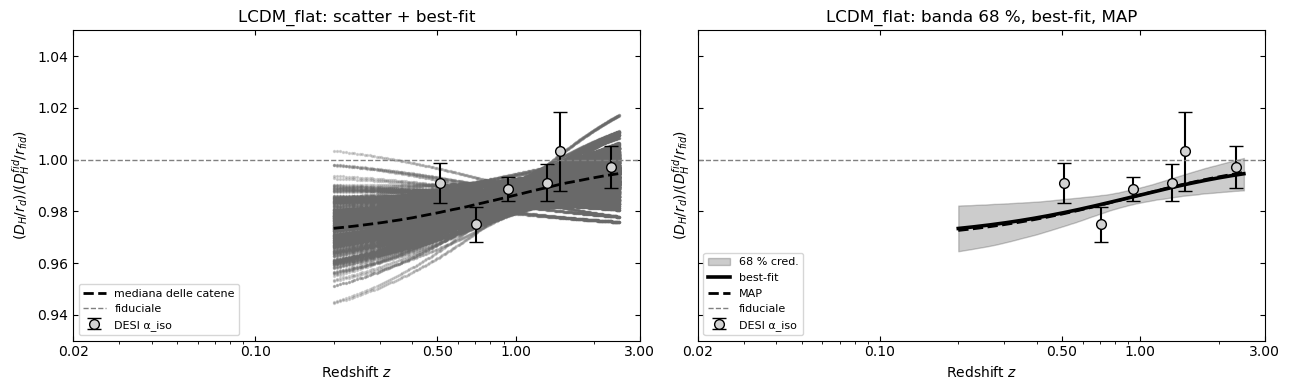

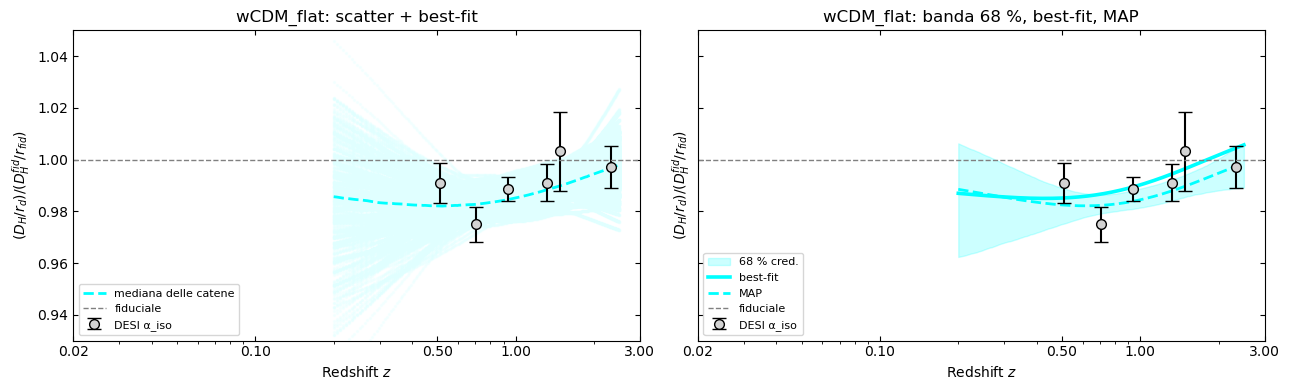

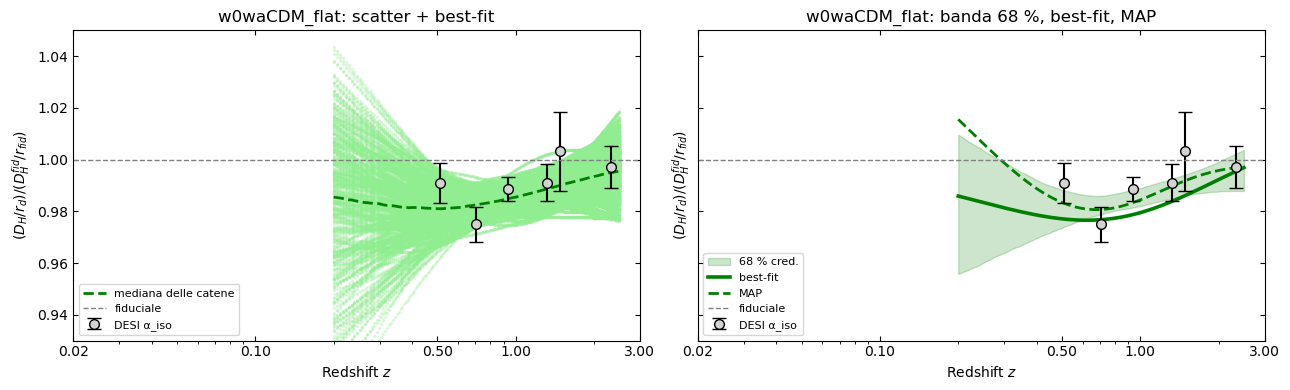

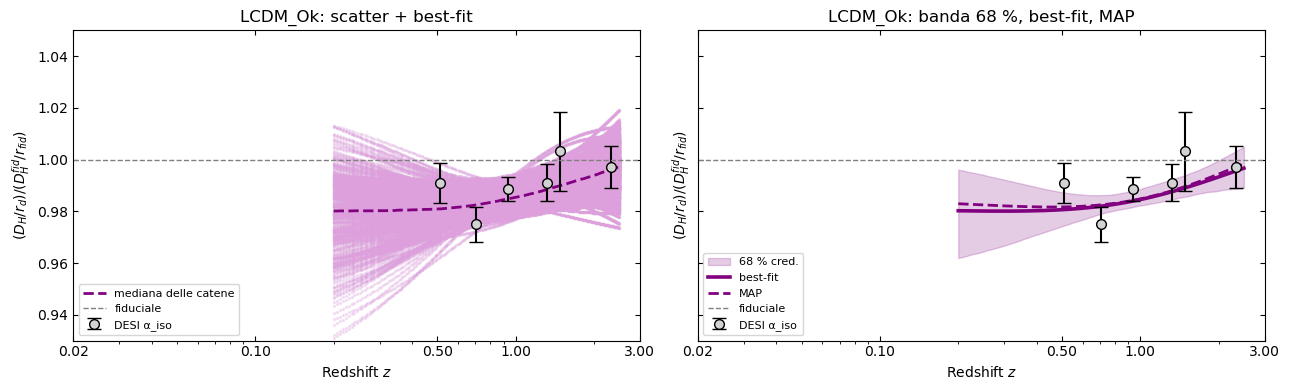

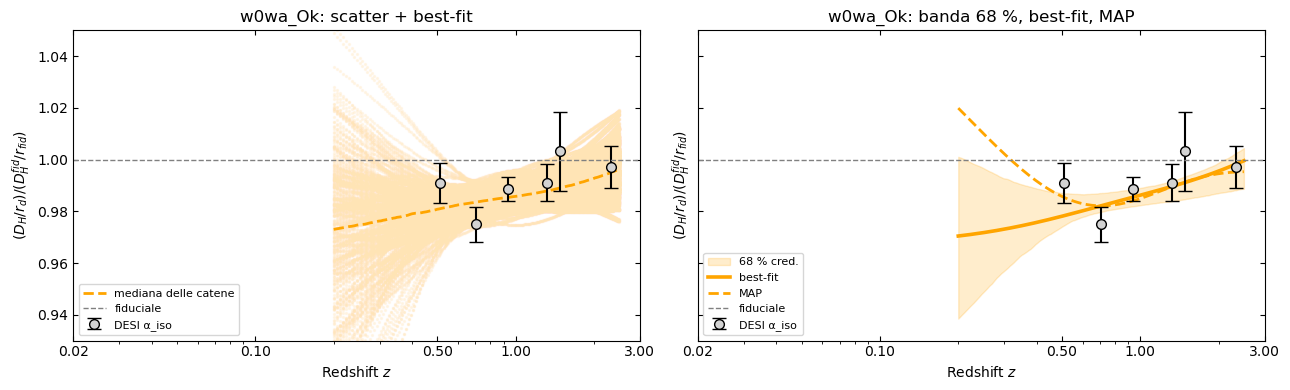

In [ ]:
burn, N_scat, N_band = nsteps//3, 300, 2000
z_dense      = np.linspace(0.2, 2.5, 400)
Dv_fid_dense = dv_model(z_dense, fid_cosmo)
results = {}

for name, cfg in models.items():
    tag, col = cfg["tag"], cfg["color"]
    chain    = samplers[name].get_chain(discard=burn, flat=True)
    if chain.size == 0:
        continue

    # mediana (best-fit) e MAP 
    best_med = np.median(chain, axis=0)
    logp     = samplers[name].get_log_prob(discard=burn, flat=True)
    best_map = chain[np.argmax(logp)]

    p16, p50, p84 = np.percentile(chain, [16, 50, 84], axis=0)
    results[name] = dict(tag=tag, p16=p16, p50=p50, p84=p84,
                         best=best_med, map=best_map)

    α_best = dv_rd_model(z_dense, build_cosmo_new(best_med, tag)) / (Dv_fid_dense/r_d_fid)
    α_map  = dv_rd_model(z_dense, build_cosmo_new(best_map, tag)) / (Dv_fid_dense/r_d_fid)

    idx_b  = rng.choice(chain.shape[0], size=min(N_band, chain.shape[0]), replace=False)
    α_mat  = np.array([
        dv_rd_model(z_dense, build_cosmo_new(th, tag)) / (Dv_fid_dense/r_d_fid)
        for th in chain[idx_b]
    ])
    α_low, α_med_fun, α_high = np.percentile(α_mat, [16,50,84], axis=0)

    idx_s  = rng.choice(chain.shape[0], size=min(N_scat, chain.shape[0]), replace=False)
    col_s  = (*plt.matplotlib.colors.to_rgb(scatter_map.get(col,"lightgray")), 0.25)

    fig, (axL, axR) = plt.subplots(1,2, figsize=(13,4), sharey=True)

    # SINISTRA
    for th in chain[idx_s]:
        α = dv_rd_model(z_dense, build_cosmo_new(th, tag)) / (Dv_fid_dense/r_d_fid)
        axL.scatter(z_dense, α, s=2, color=col_s)
    axL.plot(z_dense, α_med_fun, ls="--", lw=2.0, color=col, label="mediana delle catene")

    # DESTRA 
    axR.fill_between(z_dense, α_low, α_high, color=col, alpha=0.20, label="68 % cred.")
    axR.plot(z_dense, α_best, lw=2.6, color=col, label="best-fit")
    axR.plot(z_dense, α_map, ls="--", lw=2.0, color=col, label="MAP")

    for ax in (axL, axR):
        ax.errorbar(z_data, alpha_data, yerr=alpha_sigma,
                    fmt="o", ms=7, mfc="lightgray", mec="k",
                    ecolor="k", capsize=5, label="DESI α_iso")
        ax.axhline(1, ls="--", lw=1, color="grey", label="fiduciale")
        ax.set_xscale("log")
        ax.set_xlabel("Redshift $z$")
        ax.set_ylabel(r'$(D_H/r_d)/(D_H^{fid}/r_{fid})$')
        ax.set_xlim(0.2, 2.5); ax.set_ylim(0.93, 1.05)
        ax.set_xticks([0.02, 0.1, 0.5, 1, 3])
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.tick_params(axis='both', direction='in', top=True, right=True)
        ax.legend(fontsize=8, loc='lower left')

    axL.set_title(f"{name}: scatter + best-fit")
    axR.set_title(f"{name}: banda 68 %, best-fit, MAP")
    fig.tight_layout();  plt.show()



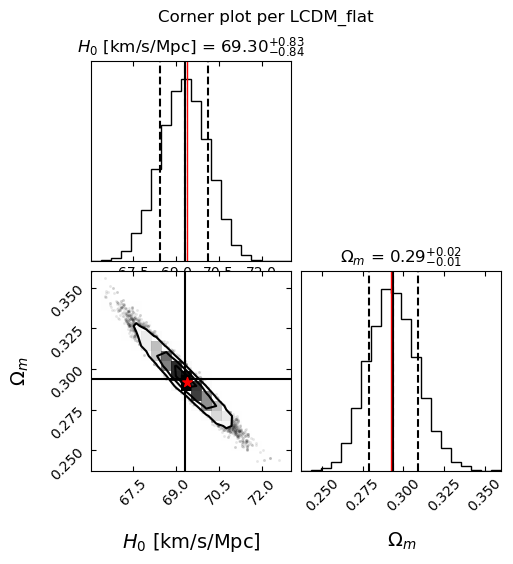

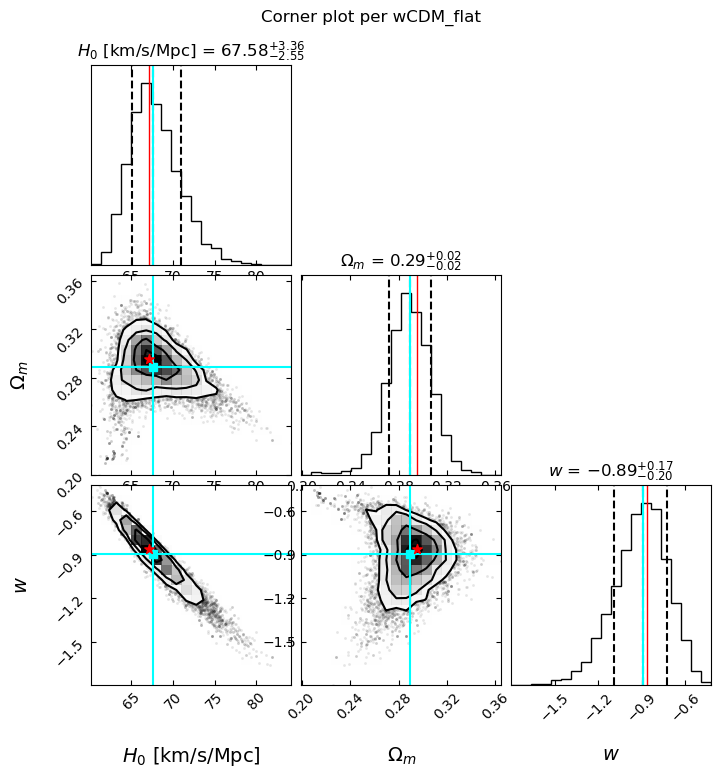

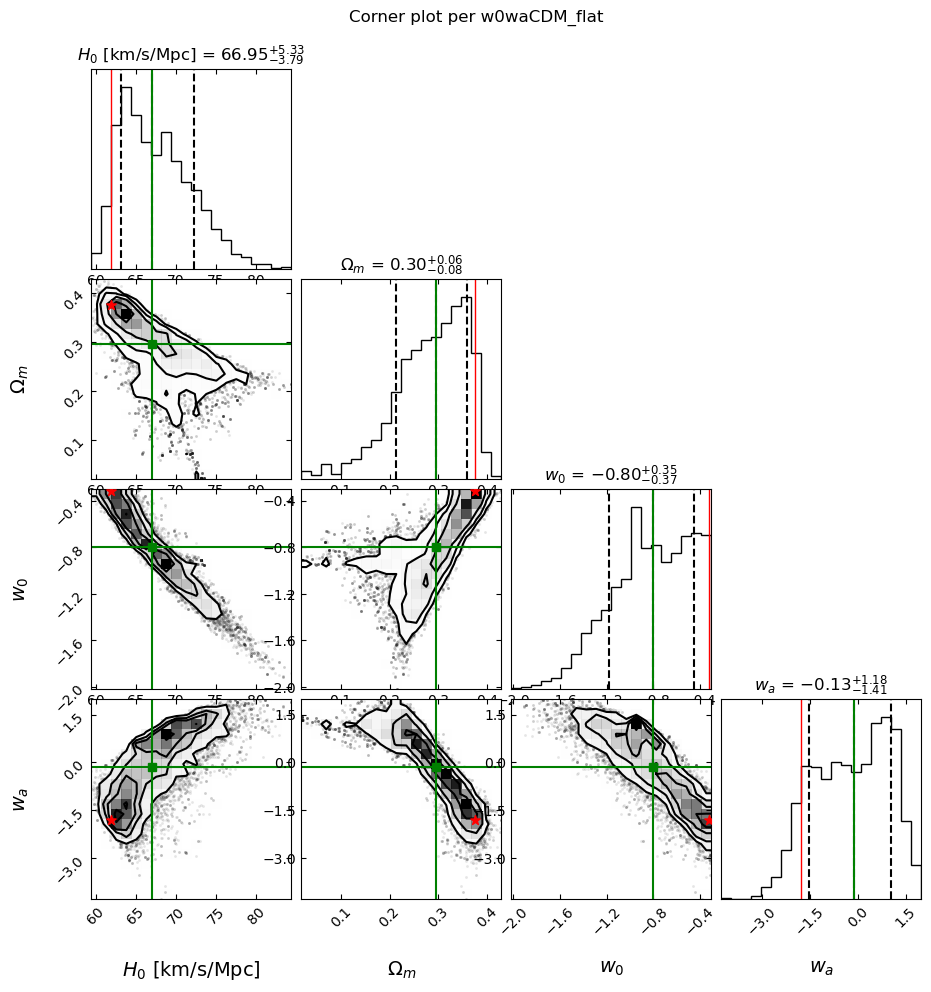

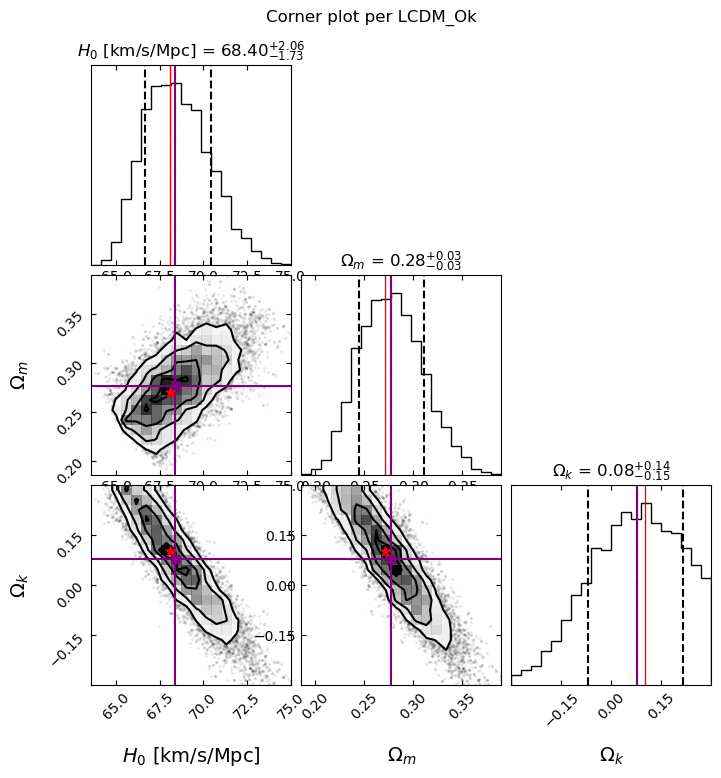

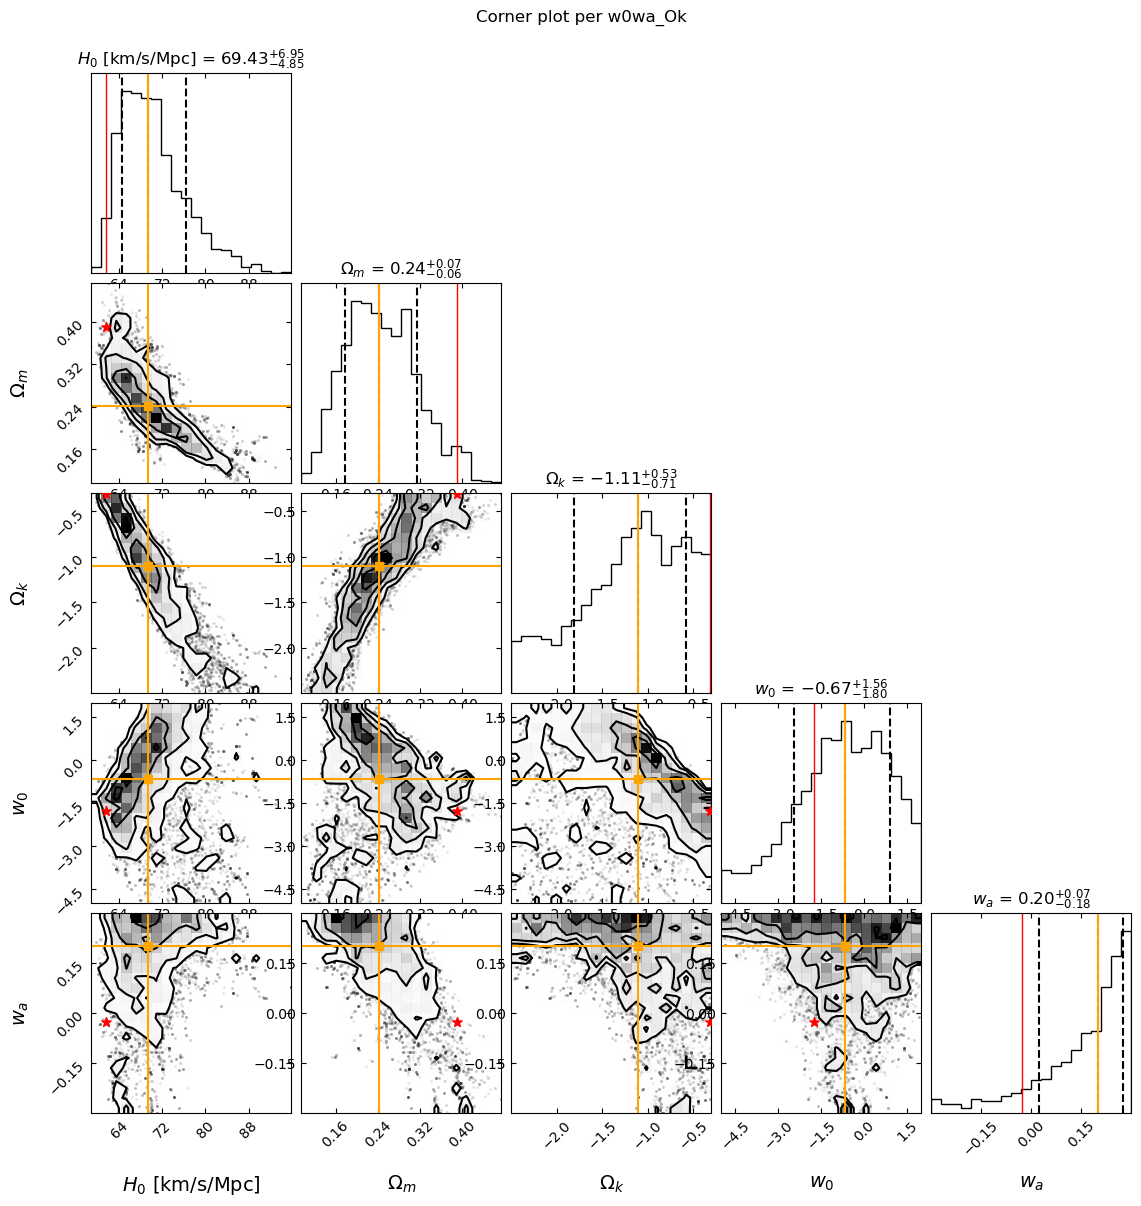

In [46]:
burn = nsteps // 3

labels_dict = {
    "LCDM_flat":    [r"$H_0\ [\mathrm{km/s/Mpc}]$", r"$\Omega_m$"],
    "wCDM_flat":    [r"$H_0\ [\mathrm{km/s/Mpc}]$", r"$\Omega_m$", r"$w$"],
    "w0waCDM_flat": [r"$H_0\ [\mathrm{km/s/Mpc}]$", r"$\Omega_m$", r"$w_0$", r"$w_a$"],
    "LCDM_Ok":      [r"$H_0\ [\mathrm{km/s/Mpc}]$", r"$\Omega_m$", r"$\Omega_k$"],
    "w0wa_Ok":      [r"$H_0\ [\mathrm{km/s/Mpc}]$", r"$\Omega_m$", r"$\Omega_k$", r"$w_0$", r"$w_a$"],
}

for name, cfg in models.items():
    ndim    = cfg["ndim"]
    sampler = samplers[name]
    chain   = sampler.get_chain(discard=burn, flat=True)
    if chain.size == 0:
        continue

    # 1) Punto MAP rosso
    logp     = sampler.get_log_prob(discard=burn, flat=True)
    map_idx  = np.argmax(logp)
    theta_map = chain[map_idx]

    # 2) Mediana marginale
    theta_med = np.median(chain, axis=0)

    # 3) Traccia la mediana con corner.corner
    fig = corner.corner(
        chain,
        labels      = labels_dict[name],
        truths      = theta_med,                   # mediana tratteggiata
        truth_color = cfg["color"],                # colore del modello
        truth_kwargs= {"linestyle":"--","linewidth":2},
        show_titles = True,
        quantiles   = [0.16, 0.5, 0.84],
        title_fmt   = ".2f",
        title_kwargs= {"fontsize":12},
        label_kwargs= {"fontsize":14},
    )

    # 4) Sovrapponi il MAP in rosso
    axes = np.array(fig.axes).reshape((ndim, ndim))
    for i in range(ndim):
        ax = axes[i, i]
        ax.axvline(theta_map[i], color="red", linestyle="-", linewidth=1)
    for yi in range(ndim):
        for xi in range(yi):
            ax = axes[yi, xi]
            ax.scatter(
                theta_map[xi],
                theta_map[yi],
                color="red",
                marker="*",
                s=50,
                zorder=10
            )

    # 5) Titolo e formattazione
    fig.suptitle(f"Corner plot per {name}", y=1.02)
    for ax in fig.axes:
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.tick_params(direction='in', top=True, right=True)

    plt.show()

In [ ]:
def f(mu, lo, hi, nd=3):
    return f"{mu:.{nd}f} (+{hi-mu:.{nd}f}/-{mu-lo:.{nd}f})"

print("\n=== Parametri cosmologici ===")
for name, d in results.items():
    tag,p16,p50,p84,mp = d["tag"],d["p16"],d["p50"],d["p84"],d["map"]
    if tag == "lcdm":
        print(f"{name}:  H0={f(p50[0],p16[0],p84[0],2)}  "
              f"Ωm={f(p50[1],p16[1],p84[1])}  "
              f"|  MAP: H0={mp[0]:.2f}, Ωm={mp[1]:.3f}")
    elif tag == "lcdm_ok":
        print(f"{name}:  H0={f(p50[0],p16[0],p84[0],2)}  "
              f"Ωm={f(p50[1],p16[1],p84[1])}  Ωk={f(p50[2],p16[2],p84[2])}  "
              f"|  MAP: {mp[0]:.2f}, {mp[1]:.3f}, {mp[2]:+.3f}")
    elif tag == "wcdm":
        print(f"{name}:  H0={f(p50[0],p16[0],p84[0],2)}  "
              f"Ωm={f(p50[1],p16[1],p84[1])}  w0={f(p50[2],p16[2],p84[2],2)}  "
              f"|  MAP: {mp[0]:.2f}, {mp[1]:.3f}, {mp[2]:+.2f}")
    else:  # w0wa (piatto o curvo)
        labs = ("H0","Ωm","w0","wa") + (("Ωk",) if "ok" in tag else ())
        med  = "  ".join(f"{lab}={f(p50[i],p16[i],p84[i],2 if lab=='H0' else 3)}"
                         for i,lab in enumerate(labs))
        map_s = ", ".join(f"{v:+.3f}" if i else f"{v:.2f}" for i,v in enumerate(mp))
        print(f"{name}:  {med}  |  MAP: {map_s}")



=== Parametri cosmologici ===
LCDM_flat:  H0=69.30 (+0.83/-0.84)  Ωm=0.294 (+0.016/-0.015)  |  MAP: H0=69.37, Ωm=0.292
wCDM_flat:  H0=67.58 (+3.36/-2.55)  Ωm=0.289 (+0.017/-0.017)  w0=-0.89 (+0.17/-0.20)  |  MAP: 67.17, 0.296, -0.86
w0wa_DESI:  H0=66.95 (+5.33/-3.79)  Ωm=0.296 (+0.062/-0.082)  w0=-0.803 (+0.351/-0.373)  wa=-0.127 (+1.179/-1.415)  |  MAP: 61.88, +0.375, -0.321, -1.789
w0wa_lit:  H0=67.04 (+5.25/-3.63)  Ωm=0.304 (+0.048/-0.066)  w0=-0.797 (+0.332/-0.395)  wa=-0.339 (+1.214/-1.195)  |  MAP: 62.32, +0.371, -0.369, -1.699
LCDM_Ok:  H0=68.20 (+2.15/-1.71)  Ωm=0.275 (+0.034/-0.030)  Ωk=0.089 (+0.130/-0.154)  |  MAP: 68.25, 0.271, +0.095
w0wa_Ok:  H0=71.12 (+6.08/-5.58)  Ωm=0.223 (+0.072/-0.054)  w0=-1.190 (+0.508/-0.783)  wa=-0.330 (+1.487/-2.088)  Ωk=0.190 (+0.078/-0.195)  |  MAP: 62.09, +0.435, -0.367, -1.409, -0.236


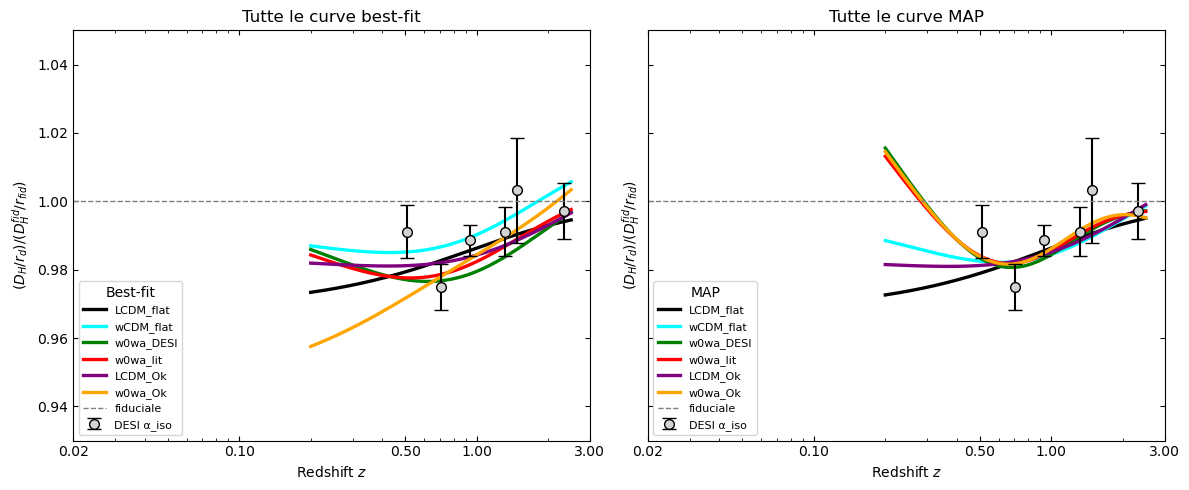

In [ ]:
z_dense      = np.linspace(0.2, 2.5, 400)
Dv_fid_dense = dv_model(z_dense, fid_cosmo)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)


for name, cfg in models.items():
    if name not in results:    
        continue
    tag      = cfg["tag"]
    col_line = cfg["color"]

    best_med = results[name]["best"]
    α_best   = dv_rd_model(z_dense, build_cosmo_new(best_med, tag)) / \
               (Dv_fid_dense / r_d_fid)
    axL.plot(z_dense, α_best, lw=2.4, color=col_line,
             label=f"{name}")
    
    best_map = results[name]["map"]
    α_map    = dv_rd_model(z_dense, build_cosmo_new(best_map, tag)) / \
               (Dv_fid_dense / r_d_fid)
    axR.plot(z_dense, α_map, lw=2.4, color=col_line,
             label=f"{name}")

for ax in (axL, axR):
    ax.errorbar(z_data, alpha_data, yerr=alpha_sigma,
                fmt="o", ms=7, mfc="lightgray", mec="k",
                ecolor="k", capsize=5, label="DESI α_iso")
    ax.axhline(1, ls="--", lw=1, color="grey", label="fiduciale")
    ax.set_xscale("log")
    ax.set_xlabel("Redshift $z$")
    ax.set_ylabel(r'$(D_H/r_d)/(D_H^{fid}/r_{fid})$')
    ax.set_xlim(0.2, 2.5); ax.set_ylim(0.93, 1.05)
    ax.set_xticks([0.02, 0.1, 0.5, 1, 3])
    from matplotlib.ticker import ScalarFormatter
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_major_formatter(ScalarFormatter())
    for s in ax.spines.values(): s.set_visible(True)
    ax.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)

axL.legend(title="Best-fit", fontsize=8, loc='lower left')
axR.legend(title="MAP", fontsize=8, loc='lower left')

axL.set_title("Tutte le curve best-fit")
axR.set_title("Tutte le curve MAP")
fig.tight_layout()
plt.show()



In questo blocco generiamo due pannelli affiancati per confrontare, su tutte le cosmologie studiate, le curve calcolate con i parametri:

- **mediana dei posteriori** (“best-fit median”)  
- **Maximum A Posteriori** (MAP)  

**`desi_ref`**: DataFrame che contiene i risultati di DESI per diversi modelli cosmologici, importato da un file CSV.
 
1. **Mappatura delle famiglie**  
   Ogni nome di modello (`LCDM_flat`, `wCDM_flat`, etc.) è associato a una “family” più generale (`LCDM`, `wCDM`, …) tramite `family_map`.  
2. **Estrazione dei parametri MAP**  
   Dal dizionario `results` si prende il vettore `d["map"]` (il punto di Maximum A Posteriori) per H₀ e Ωₘ.  
3. **Costruzione di `my_df`**  
   Si crea un DataFrame con colonne:  
   - `family`  – nome generico del modello  
   - `H0_my`   – stima MAP di H₀  
   - `Om_my`   – stima MAP di Ωₘ  

---

In [ ]:
import pandas as pd
import numpy as np

desi_ref = pd.read_csv("desi_reference_cosmos.csv")

family_map = {
    "LCDM_flat"   : "LCDM",
    "LCDM_Ok"     : "LCDM+Ok",
    "wCDM_flat"   : "wCDM",
    "w0wa_DESI"   : "w0waCDM",
    "w0wa_lit"    : "w0waCDM",
    "w0wa_Ok"     : "w0waCDM+Ok",
}

my_rows = []
for name, d in results.items():                    
    fam   = family_map.get(name)
    if fam is None: continue
    pars  = d["map"]                                 
    my_rows.append({"family": fam, "H0_my": pars[0], "Om_my": pars[1]})

my_df = pd.DataFrame(my_rows).drop_duplicates("family")

for _, my in my_df.iterrows():
    fam      = my["family"]
    theirs   = desi_ref[desi_ref["model"] == fam].copy()

    theirs["H0_my"] = my["H0_my"]
    theirs["Om_my"] = my["Om_my"]

    theirs["ΔH0 (%)"] = 100*(theirs["H0_my"] - theirs["H0"])/theirs["H0"]
    theirs["ΔOm (%)"] = 100*(theirs["Om_my"] - theirs["Om"])/theirs["Om"]

    theirs["dist2"] = theirs["ΔH0 (%)"]**2 + theirs["ΔOm (%)"]**2
    best_row = theirs.loc[theirs["dist2"].idxmin()]
    best_ds  = best_row["dataset"]
    best_pct = np.sqrt(best_row["dist2"])

    print(f"\n=== {fam}: confronto tuo modello ↔ DESI ===")
    display(theirs[["dataset","H0","H0_my","ΔH0 (%)",
                    "Om","Om_my","ΔOm (%)"]].round(3))

    print(f"→ Dataset DESI più vicino: **{best_ds}**  "
          f"(distanza ≈ {best_pct:.2f} %)\n")



=== LCDM: confronto tuo modello ↔ DESI ===


,dataset,H0,H0_my,ΔH0 (%),Om,Om_my,ΔOm (%)
0,CMB,67.14,69.369,3.320,0.317,0.292,-7.788
1,DESI,68.50,69.369,1.268,0.298,0.292,-1.774
2,DESI+BBN,68.45,69.369,1.342,0.297,0.292,-1.510
3,DESI+CMB,68.17,69.369,1.758,0.303,0.292,-3.462


→ Dataset DESI più vicino: **DESI+BBN**  (distanza ≈ 2.02 %)


=== wCDM: confronto tuo modello ↔ DESI ===


,dataset,H0,H0_my,ΔH0 (%),Om,Om_my,ΔOm (%)
7,CMB,65.80,67.169,2.081,0.296,0.296,-0.140
8,DESI,69.10,67.169,-2.794,0.300,0.296,-1.439
9,DESI+CMB,69.51,67.169,-3.368,0.297,0.296,-0.476


→ Dataset DESI più vicino: **CMB**  (distanza ≈ 2.09 %)


=== w0waCDM: confronto tuo modello ↔ DESI ===


...

→ Dataset DESI più vicino: **CMB**  (distanza ≈ 28.95 %)


=== LCDM+Ok: confronto tuo modello ↔ DESI ===


,dataset,H0,H0_my,ΔH0 (%),Om,Om_my,ΔOm (%)
4,CMB,63.3,68.246,7.814,0.354,0.271,-23.508
5,DESI,69.1,68.246,-1.235,0.293,0.271,-7.583
6,DESI+CMB,68.5,68.246,-0.370,0.303,0.271,-10.751


→ Dataset DESI più vicino: **DESI**  (distanza ≈ 7.68 %)


=== w0waCDM+Ok: confronto tuo modello ↔ DESI ===


,dataset,H0,H0_my,ΔH0 (%),Om,Om_my,ΔOm (%)
13,CMB,67.0,62.085,-7.336,0.357,0.435,21.975
14,DESI,69.2,62.085,-10.282,0.317,0.435,37.367
15,DESI+CMB,67.0,62.085,-7.336,0.323,0.435,34.815


→ Dataset DESI più vicino: **CMB**  (distanza ≈ 23.17 %)

